In [71]:
import movement
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, interpolate_over_time, rolling_filter, savgol_filter
from movement.kinematics import compute_velocity, compute_forward_vector, compute_forward_vector_angle
from pathlib import Path
import numpy as np
from movement.plots import plot_centroid_trajectory
from movement.utils.vector import cart2pol, pol2cart

import matplotlib.pyplot as plt
from scipy.signal import welch

In [4]:
Path.home()

WindowsPath('C:/Users/saram')

In [5]:
file_name = "T1_1D_04032026_inference.slp"
file_dir = Path.home() / "Desktop"/ "CollaborationDays"
file_path = file_dir/file_name
file_path.exists()

True

In [8]:
ds=load_dataset(file_path, fps=25)

In [9]:
ds

<xarray.Dataset> Size: 281kB
Dimensions:     (time: 4135, space: 2, keypoint: 5, individual: 1)
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 165kB nan ... nan
    confidence  (time, keypoint, individual) float32 83kB 0.0 0.9264 ... nan nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              25.0
    time_unit:        seconds
    source_file:      C:/Users/saram/Desktop/CollaborationDays/T1_1D_04032026...

In [19]:
ds_headcap=ds.sel(keypoint=["headcap"])

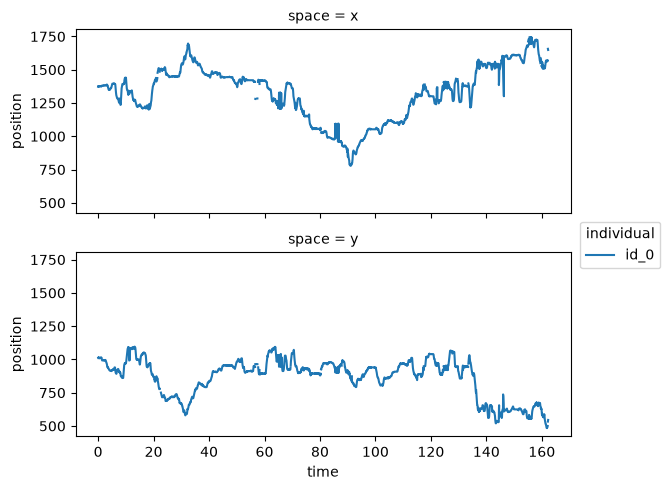

In [20]:
#we want to see the position of the headcap across space
headcap_pos=ds.position.sel(keypoint="headcap")
headcap_pos.plot.line(x="time", hue="individual", row="space", aspect=2, size=2.5)

(array([ 117.,    0.,    0.,   17.,   97.,  118.,  101.,  111.,  108.,
          88.,   99.,   86.,   74.,   74.,  103.,  132.,  316., 1562.,
         803.,   52.]),
 array([0.        , 0.05287459, 0.10574917, 0.15862375, 0.21149835,
        0.26437294, 0.31724751, 0.3701221 , 0.4229967 , 0.47587129,
        0.52874589, 0.58162045, 0.63449502, 0.68736964, 0.74024421,
        0.79311883, 0.8459934 , 0.89886796, 0.95174259, 1.00461721,
        1.05749178]),
 <BarContainer object of 20 artists>)

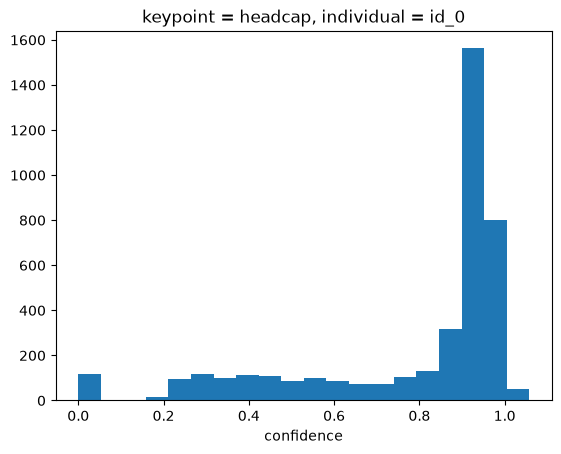

In [21]:
#Inspect outliers
ds_headcap.confidence.squeeze().plot.hist(bins=20)

In [60]:
#Filter outliers (every keypoint)
ds.update(
    {
        "position": filter_by_confidence(
            ds.position, ds.confidence, threshold=0.8, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint                 snout          right_ear           left_ear           center           headcap
individual                                                                                             
id_0        3965/4135 (95.89%)  567/4135 (13.71%)  576/4135 (13.93%)  77/4135 (1.86%)  194/4135 (4.69%)
Missing points (marked as NaN) in output:

keypoint                 snout           right_ear            left_ear           center            headcap
individual                                                                                                
id_0        4129/4135 (99.85%)  1293/4135 (31.27%)  1486/4135 (35.94%)  77/4135 (1.86%)  1282/4135 (31.0%)


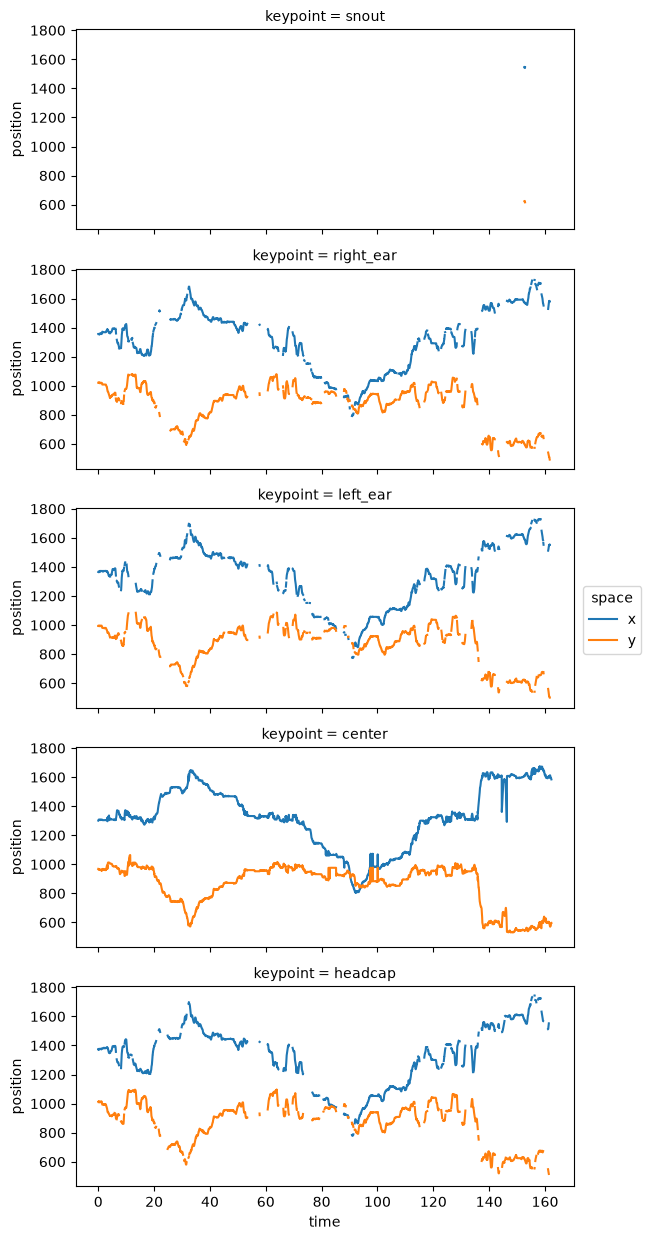

In [62]:
#Check filtering
ds.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [63]:
#Interpolate filtered data
ds.update(
    {
        "position": interpolate_over_time(
            ds.position, max_gap=40, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint                 snout           right_ear            left_ear           center            headcap
individual                                                                                                
id_0        4129/4135 (99.85%)  1293/4135 (31.27%)  1486/4135 (35.94%)  77/4135 (1.86%)  1282/4135 (31.0%)
Missing points (marked as NaN) in output:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4126/4135 (99.78%)  578/4135 (13.98%)  603/4135 (14.58%)  77/4135 (1.86%)  655/4135 (15.84%)


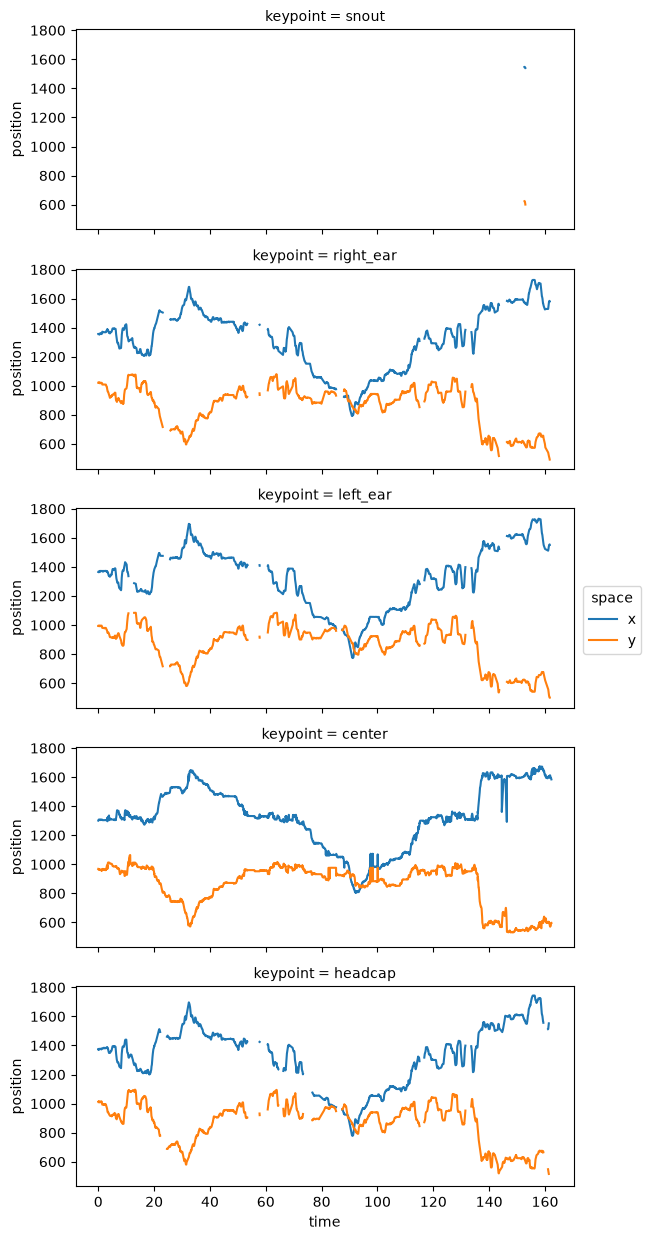

In [64]:
#Check interpolation
ds.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [65]:
#Generate pipeline log
print(ds.position.log)

[
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 14:48:58.754745",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 5, individual: 1)> Size: 83kB\n0.0 0.9264 0.9678 0.9671 0.9351 0.0 0.9788 1.003 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4\n  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'\n  * individual  (individual) <U4 16B 'id_0'",
    "threshold": "0.8",
    "print_report": "True"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 14:49:46.549587",
    "method": "'linear'",
    "max_gap": "40",
    "print_report": "True"
  }
]


In [66]:
#smoothing the tracking
window=int(0.3*ds.fps)
ds_smooth=ds.copy ()
ds_smooth.update({"position":rolling_filter(ds.position, window, min_periods=2, statistic="median", print_report=True)})

Missing points (marked as NaN) in input:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4126/4135 (99.78%)  578/4135 (13.98%)  603/4135 (14.58%)  77/4135 (1.86%)  655/4135 (15.84%)
Missing points (marked as NaN) in output:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4122/4135 (99.69%)  548/4135 (13.25%)  569/4135 (13.76%)  75/4135 (1.81%)  617/4135 (14.92%)


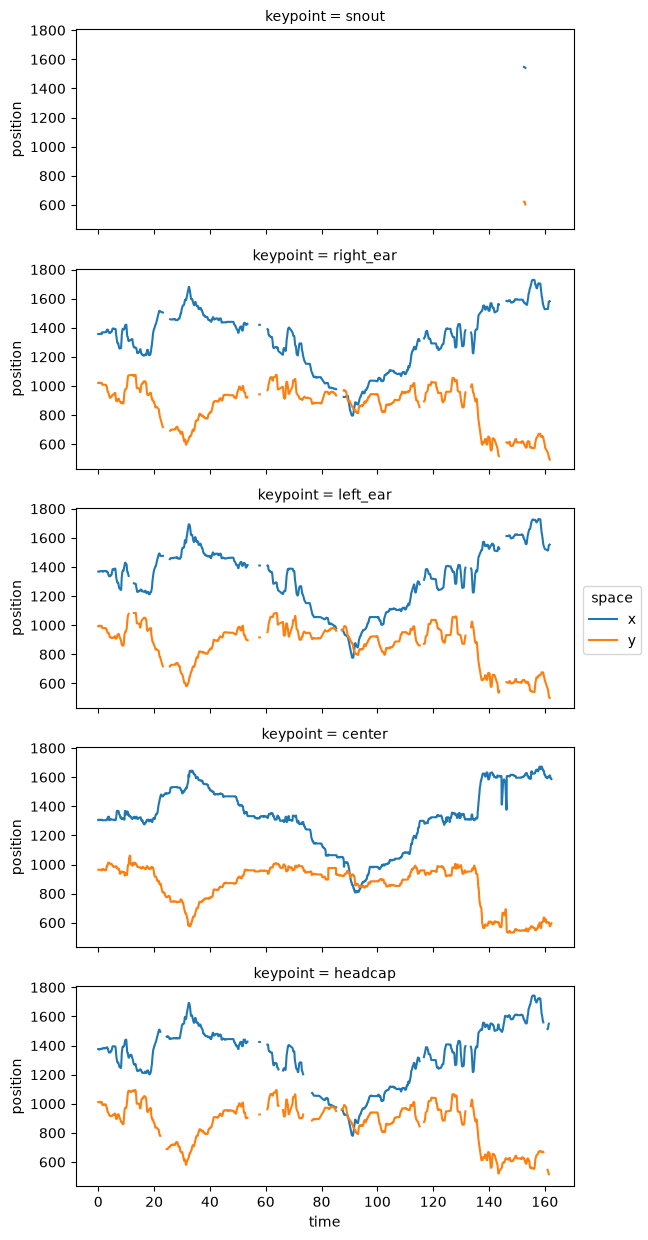

In [68]:
#plotting the output of the smoothing
ds_smooth.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [69]:
ds_smooth.position

<xarray.DataArray 'position' (time: 4135, space: 2, keypoint: 5, individual: 1)> Size: 165kB
nan 1.357e+03 1.369e+03 1.305e+03 1.376e+03 nan ... nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...

2026-08-21 15:23:54.538 | WARNING  | matplotlib._api:warn_external:494 - C:\Users\saram\AppData\Local\Temp\ipykernel_23604\2033064749.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



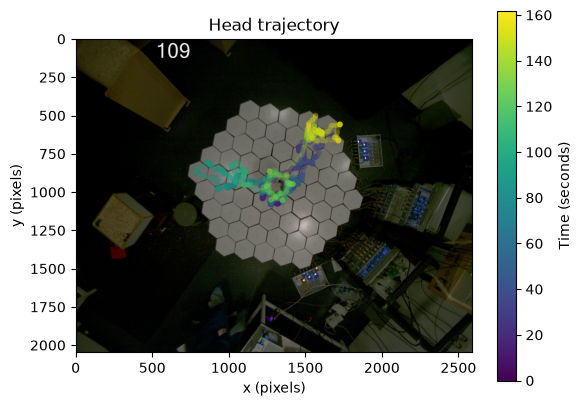

In [81]:
#compute head direction
##Visualise the head trajectory

frame_path= file_dir/ "vlcsnap-2026-08-21-15h13m03s667.png"
# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot a single frame from the dataset (its path is stored as an attribute)
frame = plt.imread(frame_path)
ax.imshow(frame)

# Plot the trajectory of the head centre
plot_centroid_trajectory(
    ds_smooth.position,
    keypoints=["left_ear", "right_ear"],
    ax=ax,
    # arguments forwarded to plt.scatter
    s=10,
    cmap="viridis",
    marker="o",
    alpha=0.05,
)

# Adjust title
ax.set_title("Head trajectory")
ax.set_ylim(frame.shape[0], 0)  # match y-axis limits to image coordinates
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.collections[0].colorbar.set_label("Time (seconds)")
fig.show()

In [82]:
#Compute the head-to-headcap vector

# Compute the head centre as the midpoint between the ears
midpoint_ears = ds_smooth.position.sel(keypoint=["left_ear", "right_ear"]).mean(
    dim="keypoint"
)
# Snout position
# (`drop=True` removes the keypoint dimension, which is now redundant)
headcap = ds_smooth.position.sel(keypoint="headcap", drop=True)

# Compute the head vector as the difference vector between the snout position
# and the head-centre position.
head_to_headcap = headcap - midpoint_ears

In [83]:
print(head_to_headcap)

<xarray.DataArray 'position' (time: 4135, space: 2, individual: 1)> Size: 33kB
13.16 5.569 12.92 5.569 13.24 5.494 13.45 4.198 ... nan nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...


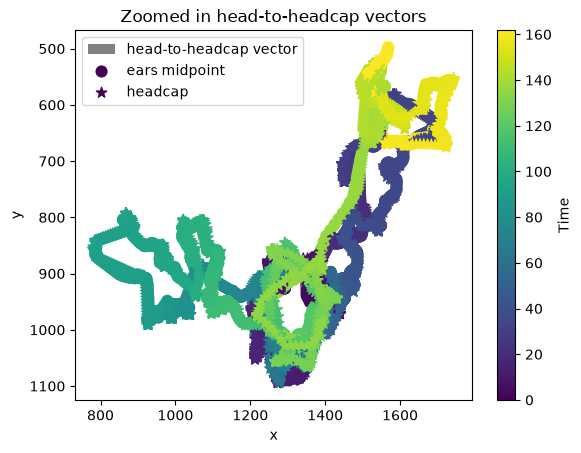

In [94]:
# Time window to restrict the plot
time_window = slice(0, 1000)  # seconds

fig, ax = plt.subplots()

# Plot the computed head-to-snout vector originating from the ears midpoint
ax.quiver(
    midpoint_ears.sel(space="x", time=time_window),
    midpoint_ears.sel(space="y", time=time_window),
    head_to_headcap.sel(space="x", time=time_window),
    head_to_headcap.sel(space="y", time=time_window),
    color="gray",
    angles="xy",
    scale=1,
    scale_units="xy",
    headwidth=4,
    headlength=5,
    headaxislength=5,
    label="head-to-headcap vector",
)

# Plot midpoint between the ears within the time window
plot_centroid_trajectory(
    midpoint_ears.sel(time=time_window),
    ax=ax,
    s=60,
    label="ears midpoint",
)

# Plot the snout position within the time window
plot_centroid_trajectory(
    headcap.sel(time=time_window),
    ax=ax,
    s=60,
    marker="*",
    label="headcap",
)

# Calling plot_centroid_trajectory twice will add 2 identical colorbars
# so we remove 1
ax.collections[2].colorbar.remove()

ax.set_title("Zoomed in head-to-headcap vectors")
ax.invert_yaxis()  # invert y-axis to match image coordinates
ax.legend(loc="upper left")

In [89]:
head_to_headcap_polar = cart2pol(head_to_headcap)

print(head_to_headcap_polar)

<xarray.DataArray 'position' (time: 4135, space_pol: 2, individual: 1)> Size: 33kB
14.29 0.4004 14.07 0.407 14.33 0.3934 14.09 ... nan nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space_pol   (space_pol) <U3 24B 'rho' 'phi'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...


In [95]:
head_to_headcap_cart = pol2cart(head_to_headcap_polar)
print(head_to_headcap_cart)

<xarray.DataArray 'position' (time: 4135, space: 2, individual: 1)> Size: 33kB
13.16 5.569 12.92 5.569 13.24 5.494 13.45 4.198 ... nan nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...


In [96]:
forward_vector = compute_forward_vector(
    ds_smooth.position,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    camera_view="top_down",
)
print(forward_vector)

<xarray.DataArray 'forward_vector' (time: 4135, space: 2, individual: 1)> Size: 66kB
0.9234 0.3839 0.9234 0.3839 0.9214 0.3886 0.8996 ... nan nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...


In [97]:
forward_vector_angle = compute_forward_vector_angle(
    ds_smooth.position,
    left_keypoint="left_ear",
    right_keypoint="right_ear",
    # Optional parameters:
    reference_vector=(1, 0),  # positive x-axis
    camera_view="top_down",
    in_degrees=False,  # set to True for degrees
)
print(forward_vector_angle)

<xarray.DataArray 'forward_vector_angle' (time: 4135, individual: 1)> Size: 33kB
0.394 0.394 0.3992 0.4518 0.4546 0.4116 0.4114 ... nan nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...


In [99]:
def plot_polar_histogram(da, bin_width_deg=15, ax=None):
    """Plot a polar histogram of the data in the given DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        A DataArray containing angle data in radians.
    bin_width_deg : int, optional
        Width of the bins in degrees.
    ax : matplotlib.axes.Axes, optional
        The axes on which to plot the histogram.

    """
    n_bins = int(360 / bin_width_deg)

    if ax is None:
        fig, ax = plt.subplots(  # initialise figure with polar projection
            1, 1, figsize=(5, 5), subplot_kw={"projection": "polar"}
        )
    else:
        fig = ax.figure  # or use the provided axes

    # plot histogram using xarray's built-in histogram function
    da.plot.hist(
        bins=np.linspace(-np.pi, np.pi, n_bins + 1), ax=ax, density=True
    )

    # axes settings
    ax.set_theta_direction(-1)  # theta increases in clockwise direction
    ax.set_theta_offset(0)  # set zero at the right
    ax.set_xlabel("")  # remove default x-label from xarray's plot.hist()

    # set xticks to match the phi values in degrees
    n_xtick_edges = 9
    ax.set_xticks(np.linspace(0, 2 * np.pi, n_xtick_edges)[:-1])
    xticks_in_deg = (
        list(range(0, 180 + 45, 45)) + list(range(0, -180, -45))[-1:0:-1]
    )
    ax.set_xticklabels([str(t) + "\N{DEGREE SIGN}" for t in xticks_in_deg])

    return fig, ax

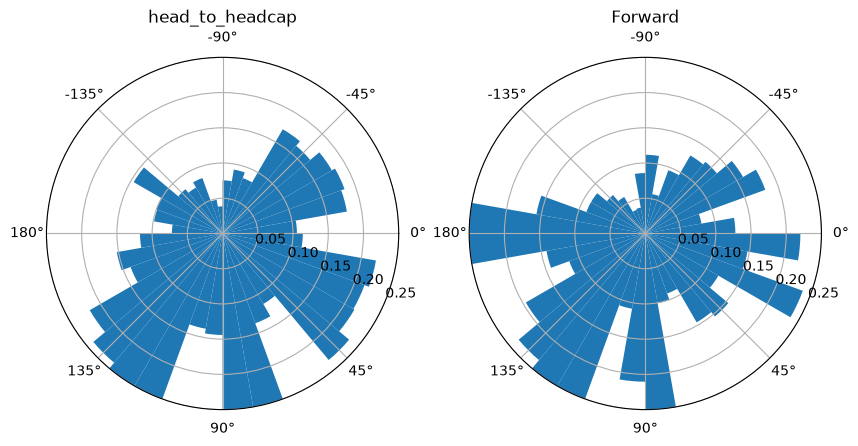

In [100]:
head_to_headcap_angle = head_to_headcap_polar.sel(space_pol="phi")
angle_arrays = [head_to_headcap_angle, forward_vector_angle]
angle_titles = ["head_to_headcap", "Forward"]

fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}
)
for i, angles in enumerate(angle_arrays):
    title = angle_titles[i]
    ax = axes[i]
    plot_polar_histogram(angles, bin_width_deg=10, ax=ax)
    ax.set_ylim(0, 0.25)  # force same y-scale (density) for both plots
    ax.set_title(title, pad=25)

Text(0.5, 1.0, 'Forward vector angle - head_to_headcap angle')

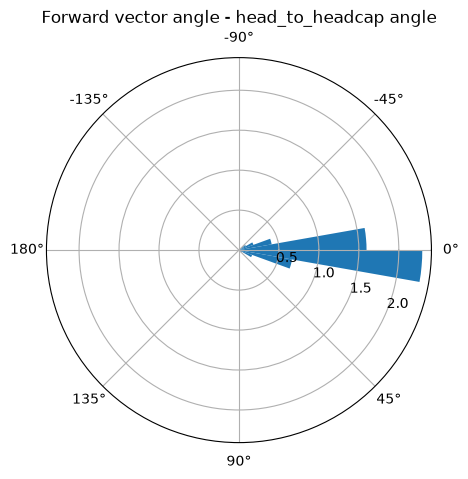

In [101]:
angles_diff = forward_vector_angle - head_to_headcap_angle
fig, ax = plot_polar_histogram(angles_diff, bin_width_deg=10)
ax.set_title("Forward vector angle - head_to_headcap angle", pad=25)